# TensorFlow를 활용한 선형회귀 실습

이 노트북에서는 TensorFlow를 사용하여 간단한 선형회귀 문제를 풀어봅니다.

## 주요 단계
1. 데이터 생성 (y = 3x + 2 + 잡음)
2. 모델 정의 (Dense Layer)
3. 손실 함수 및 최적화 방법 설정
4. 학습 진행 및 시각화


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.10.1


## 1. 데이터 생성

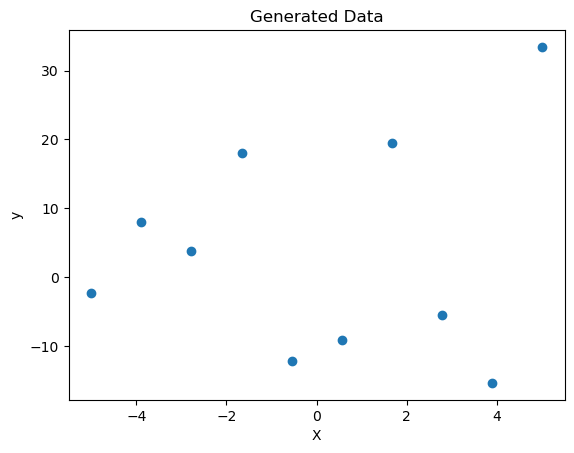

In [8]:
# y = 3x + 2 + noise
n_samples = 10
X = np.linspace(-5, 5, n_samples)
y = 3 * X + 2 + np.random.normal(0, 1, n_samples)*20

plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Generated Data")
plt.show()

## 2. 모델 정의

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(1,)),
    tf.keras.layers.Dense(1)
])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


## 3. 모델 컴파일
- 손실 함수: MSE (Mean Squared Error)
- 최적화 방법: SGD (Stochastic Gradient Descent)

In [10]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
              loss='mse')

## 4. 모델 학습

Epoch 1/200
1/1 - 0s - loss: 265.9663 - 334ms/epoch - 334ms/step
Epoch 2/200
1/1 - 0s - loss: 254.3809 - 7ms/epoch - 7ms/step
Epoch 3/200
1/1 - 0s - loss: 246.8410 - 8ms/epoch - 8ms/step
Epoch 4/200
1/1 - 0s - loss: 241.8741 - 9ms/epoch - 9ms/step
Epoch 5/200
1/1 - 0s - loss: 238.5461 - 8ms/epoch - 8ms/step
Epoch 6/200
1/1 - 0s - loss: 236.2642 - 7ms/epoch - 7ms/step
Epoch 7/200
1/1 - 0s - loss: 234.6526 - 9ms/epoch - 9ms/step
Epoch 8/200
1/1 - 0s - loss: 233.4724 - 8ms/epoch - 8ms/step
Epoch 9/200
1/1 - 0s - loss: 232.5722 - 8ms/epoch - 8ms/step
Epoch 10/200
1/1 - 0s - loss: 231.8554 - 8ms/epoch - 8ms/step
Epoch 11/200
1/1 - 0s - loss: 231.2607 - 10ms/epoch - 10ms/step
Epoch 12/200
1/1 - 0s - loss: 230.7490 - 9ms/epoch - 9ms/step
Epoch 13/200
1/1 - 0s - loss: 230.2953 - 7ms/epoch - 7ms/step
Epoch 14/200
1/1 - 0s - loss: 229.8834 - 6ms/epoch - 6ms/step
Epoch 15/200
1/1 - 0s - loss: 229.5030 - 11ms/epoch - 11ms/step
Epoch 16/200
1/1 - 0s - loss: 229.1472 - 8ms/epoch - 8ms/step
Epoch 17/

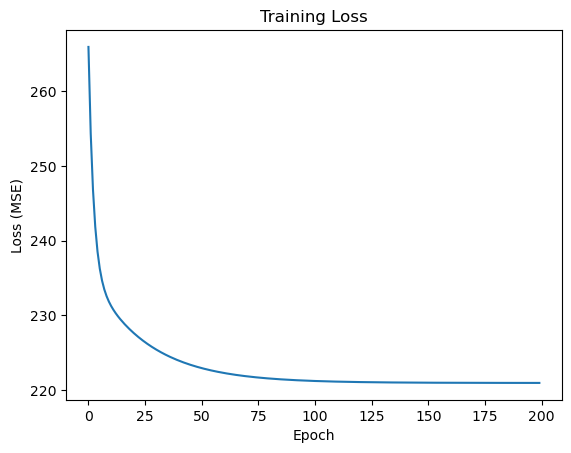

In [11]:
history = model.fit(X, y, epochs=200, verbose=2)

plt.plot(history.history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss')
plt.show()

## 5. 결과 확인

학습된 기울기 W: 0.645, 절편 b: 3.803
1/1 [==============================] - 0s 64ms/step


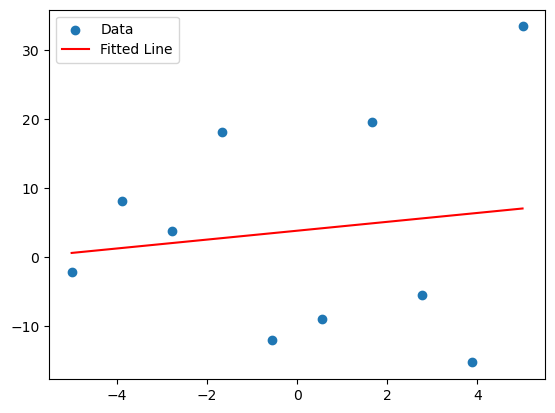

In [12]:
W, b = model.layers[0].get_weights()
print(f"학습된 기울기 W: {W[0][0]:.3f}, 절편 b: {b[0]:.3f}")

y_pred = model.predict(X)

plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Fitted Line')
plt.legend()
plt.show()

## 생각해보기
- 학습 샘플 수가 작아지면 어떻게 되는가?

과적합이 발생 한다

- 학습 샘플에 잡음이 많으면 어떻게 되는가? 이 경우 학습 데이터가 많이 필요한가?

과적합 발생 한다, 학습 셈플은 많을 수록 좋다.